# Radiation test data

- Download required MSG and ERA5 data from a product list
- Add radiation data from MSG to the dataset
- Add ozone and temperature data from era5 to the dataset
- Write files needed as input and output for test (except CAMS and water column which is already available in S2/Maja product) : albedo, rsd, rld, fdiffuse, ozone et température

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datetime as dt
import os

import rasterio as rio
from pyproj import CRS
from sensorsio import utils


In [3]:
from etdataset import msg
from etdataset import dem
from etdataset import era5
from etdataset.interpolation import create_grid_dataset
from etdataset.utils import read_product_list
from etdataset.writer import write_dataset
from etdataset.reader import get_product_reader

# Logging

In [4]:
import logging
from etdataset.logging import LoggerManager

LoggerManager.set_level(logging.INFO)

## Inputs / Outputs

In [5]:
S2_dir = "S2" # to be modified to point on the directory containing S2 files

In [5]:
DEM_dir = "dem" # to be modified to point on the directory containing DEM files

In [6]:
data_dir = "data_aux" # to be modified to point on the directory containing auxiliary data with sub-directories named MSG_data, ERA5_data,

In [6]:
product_list = os.listdir(S2_dir)

In [7]:
product_list

['SENTINEL2A_20220510-105902-538_L2A_T31TCJ_C_V4-0',
 'SENTINEL2A_20221007-105905-289_L2A_T31TCJ_C_V4-0',
 'SENTINEL2A_20221116-105900-864_L2A_T31TCJ_C_V4-0',
 'SENTINEL2A_20220709-105911-692_L2A_T31TCJ_C_V4-0',
 'SENTINEL2A_20230214-105856-118_L2A_T31TCJ_C_V4-0',
 'SENTINEL2A_20220917-105907-537_L2A_T31TCJ_C_V4-0',
 'SENTINEL2A_20221106-105902-793_L2A_T31TCJ_C_V4-0',
 'SENTINEL2A_20230316-105856-234_L2A_T31TCJ_C_V4-0',
 'SENTINEL2A_20220828-105908-843_L2A_T31TCJ_C_V4-0']

In [9]:
output_dir = "out" # to be modified to point on the output directory

## Select data

In [8]:
product_index = 0 # to be modified to point the data product to process

In [9]:
product_path = os.path.join(S2_dir,product_list[product_index])

In [10]:
product_path

'/home/adupuis/Documents/radiation/data/S2/SENTINEL2A_20220510-105902-538_L2A_T31TCJ_C_V4-0'

# Read Data

In [13]:
reader = get_product_reader(product_path=product_path)

In [14]:
s2_dataset = reader.read_vis_bands()

In [15]:
date = dt.datetime(2024, 10, 21, 10, 33)

# Add DEM

In [17]:
s2_dataset = dem.add_dem(data=s2_dataset,mnt_dir=DEM_dir)

tile id  : ['31TCJ']


In [ ]:
s2_dataset

# Manage CRS and date

In [18]:
crs=s2_dataset.rio.crs
bounds = rio.coords.BoundingBox(*s2_dataset.rio.bounds())

In [19]:
s2_dataset.attrs

{'tile': '31TCJ',
 'transform': Affine(60.0, 0.0, np.float64(300000.0),
        0.0, -60.0, np.float64(4900080.0)),
 'vis': 'Sentinel2',
 'vis_date': datetime.date(2022, 5, 10),
 'vis_time': datetime.time(10, 59, 2)}

In [20]:
s2_dataset.data_vars

Data variables:
    blue      (y, x) float32 13MB 0.0499 0.04 0.0365 ... 0.0998 0.1121 nan
    green     (y, x) float32 13MB 0.0693 0.0639 0.0753 0.1 ... 0.1614 0.177 nan
    red       (y, x) float32 13MB 0.0613 0.0671 0.0654 ... 0.2003 0.2164 nan
    red_edge  (y, x) float32 13MB 0.276 0.2713 0.2856 ... 0.2552 0.2756 nan
    nir       (y, x) float32 13MB 0.3794 0.3803 0.3728 ... 0.2775 0.2985 nan
    nir2      (y, x) float32 13MB 0.4041 0.3985 0.3911 ... 0.2861 0.3096 nan
    swir1     (y, x) float32 13MB 0.1577 0.1598 0.1774 ... 0.3545 0.3709 nan
    swir2     (y, x) float32 13MB 0.0978 0.0986 0.1095 ... 0.2817 0.2924 nan
    water     (y, x) bool 3MB False False False False ... False False False
    cloud     (y, x) int64 27MB 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1 1
    qa        (y, x) uint8 3MB 1 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1 1
    ndvi      (y, x) float32 13MB 0.7218 0.7 0.7015 0.5433 ... 0.1616 0.1594 nan
    lai       (y, x) float64 27MB 1.381 1.276 1.28

In [21]:
latlon_bounds = utils.bb_transform(
        source_crs=str(crs), target_crs="EPSG:4326", bounding_box=bounds
    )

In [22]:
date = dt.datetime.combine(s2_dataset.attrs["vis_date"], s2_dataset.attrs["vis_time"])

# Add MSG data

In [23]:
msg.download(date=date, latlon_bbox=latlon_bounds, path=data_dir)

25-09-10 15:07:36 :: INFO :: File /home/adupuis/Documents/radiation/data/MSG_data/MSG_2022-05-10/NETCDF4_LSASAF_MSG_DIDSSF_MSG-Disk_202205100000.nc already exists. Skip download.
25-09-10 15:07:36 :: INFO :: File /home/adupuis/Documents/radiation/data/MSG_data/MSG_2022-05-10/NETCDF4_LSASAF_MSG_MDSSFTD_MSG-Disk_202205101030.nc already exists. Skip download.
25-09-10 15:07:36 :: INFO :: File /home/adupuis/Documents/radiation/data/MSG_data/MSG_2022-05-10/NETCDF4_LSASAF_MSG_MDSSFTD_MSG-Disk_202205101045.nc already exists. Skip download.
25-09-10 15:07:36 :: INFO :: File /home/adupuis/Documents/radiation/data/MSG_data/MSG_2022-05-10/NETCDF4_LSASAF_MSG_MDSSFTD_MSG-Disk_202205101100.nc already exists. Skip download.
25-09-10 15:07:36 :: INFO :: File /home/adupuis/Documents/radiation/data/MSG_data/MSG_2022-05-10/NETCDF4_LSASAF_MSG_DSLF_MSG-Disk_202205101000.nc already exists. Skip download.
25-09-10 15:07:36 :: INFO :: File /home/adupuis/Documents/radiation/data/MSG_data/MSG_2022-05-10/NETCDF4

In [24]:
s2_dataset = msg.add(data=s2_dataset,path=data_dir)

In [ ]:
s2_dataset

# Add era5 data

In [27]:
era5.download(date=date, dataset=era5.ERA5Dataset.ERA5, path=data_dir)

25-09-10 15:07:39 :: INFO :: File /home/adupuis/Documents/radiation/data/ERA5_data/download_era5_2022-05-10.zip already exits. Skip download.


In [28]:
s2_dataset = era5.add(data=s2_dataset, dataset=era5.ERA5Dataset.ERA5, path=data_dir)

25-09-10 15:07:47 :: WARNING :: DEM is missing in ERA5 data: No variables 'height' in the dataset


In [29]:
s2_dataset

<xarray.Dataset> Size: 476MB
Dimensions:      (y: 1831, x: 1831)
Coordinates:
  * x            (x) float64 15kB 3e+05 3.001e+05 ... 4.098e+05 4.098e+05
  * y            (y) float64 15kB 4.9e+06 4.9e+06 4.9e+06 ... 4.79e+06 4.79e+06
    spatial_ref  int64 8B 0
Data variables: (12/26)
    blue         (y, x) float32 13MB 0.0499 0.04 0.0365 ... 0.0998 0.1121 nan
    green        (y, x) float32 13MB 0.0693 0.0639 0.0753 ... 0.1614 0.177 nan
    red          (y, x) float32 13MB 0.0613 0.0671 0.0654 ... 0.2003 0.2164 nan
    red_edge     (y, x) float32 13MB 0.276 0.2713 0.2856 ... 0.2552 0.2756 nan
    nir          (y, x) float32 13MB 0.3794 0.3803 0.3728 ... 0.2775 0.2985 nan
    nir2         (y, x) float32 13MB 0.4041 0.3985 0.3911 ... 0.2861 0.3096 nan
    ...           ...
    rld_msg      (y, x) float64 27MB 370.5 370.5 370.5 ... 335.6 335.6 335.6
    ta           (y, x) float64 27MB nan nan nan nan ... 297.2 297.2 297.3 nan
    tdp          (y, x) float64 27MB nan nan nan nan ... 285.4 285.4 285.5 nan
    rsd_era5     (y, x) float64 27MB 817.3 817.3 817.3 ... 859.2 859.2 859.2
    rld_era5     (y, x) float64 27MB 346.6 346.6 346.6 ... 328.9 328.9 328.9
    tco3_era5    (y, x) float64 27MB 0.007014 0.007014 ... 0.007168 0.007168
Attributes:
    tile:       31TCJ
    transform:  | 60.00, 0.00, 300000.00|\n| 0.00,-60.00, 4900080.00|\n| 0.00...
    vis:        Sentinel2
    vis_date:   2022-05-10
    vis_time:   10:59:02
    tir:        Sentinel2

# Write data

In [25]:
# Simulate TIR data because it is used do define output directory name
s2_dataset.attrs["tir"] = s2_dataset.attrs["vis"]

In [30]:
write_dataset(xrds=s2_dataset,bands=None, directory=output_dir, separate=True)

# Visualisations

/home/adupuis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


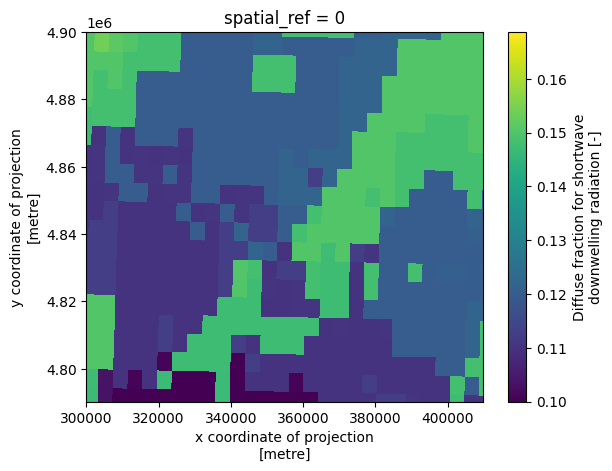

In [31]:
s2_dataset.fdiff_msg.plot()

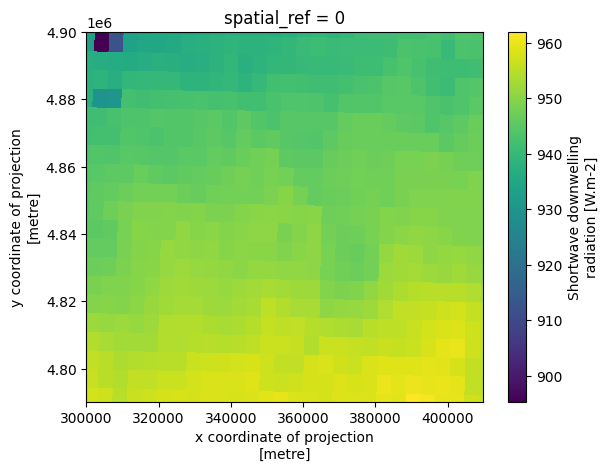

In [32]:
s2_dataset.rsd_msg.plot()

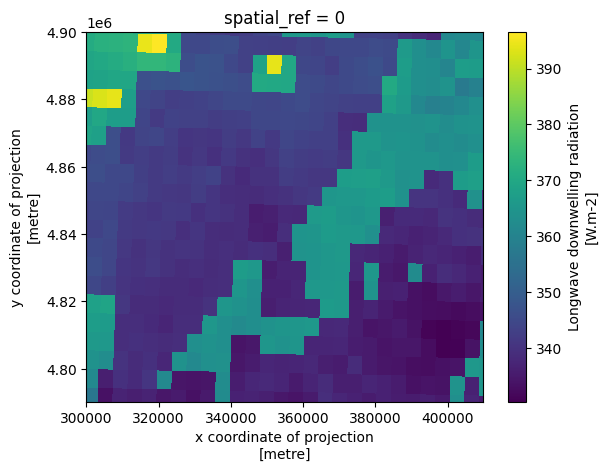

In [33]:
s2_dataset.rld_msg.plot()

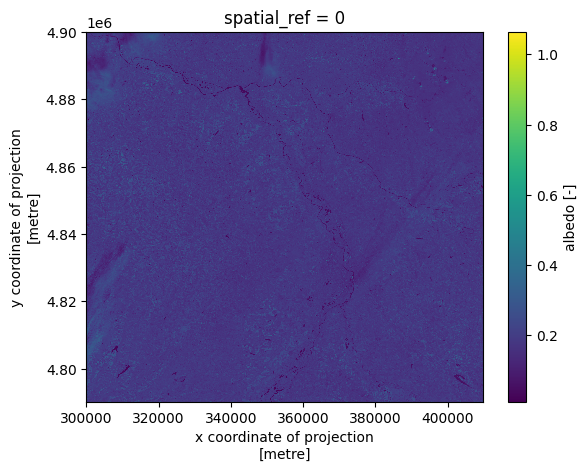

In [34]:
s2_dataset.albedo.plot()